In [21]:
from workflow.preprocess import *
from workflow.SQUIC_functions import *

import matplotlib.pyplot as plt
import json
import numpy as np
import networkx as nx
from networkx.algorithms import community
from cosmograph import cosmo
from IPython.display import display


def parse_input(user_input):
    """Parse and validate the dataset input in the format NAME_DIMENSION."""
    try:
        name, dimension = user_input.strip().upper().split("_")
    except ValueError:
        raise ValueError("Input must be in the format NAME_DIMENSION (e.g., AMLSIM_10K)")

    valid_names = {"AMLSIM", "PAYSIM", "LIBRE"}
    valid_dimensions = {"100", "1K", "10K", "100K", "1M"}

    if name not in valid_names:
        raise ValueError(f"Invalid dataset name '{name}'. Valid options are: {', '.join(valid_names)}")
    if dimension not in valid_dimensions:
        raise ValueError(f"Invalid dimension '{dimension}'. Valid options are: {', '.join(valid_dimensions)}")

    return name, dimension


def load_dataset():
    """Prompt user input and load the corresponding dataset."""
    while True:
        user_input = input("Insert dataset name in the following format NAME_DIMENSION (e.g., AMLSIM_10K): ")

        try:
            name, dimension = parse_input(user_input)
            break
        except ValueError as e:
            print(f"Error: {e}")
            continue

    if name == 'AMLSIM':
        df = AMLSim_preprocessing(dimension)
    elif name == 'PAYSIM':
        df = PaySim_preprocessing(dimension)
    elif name == 'LIBRE':
        # future implementation
        df = None
        print("LIBRE dataset support not yet implemented.")
    else:
        df = None

    return df, name, dimension

def extract_timeseries(df):
    # Plot the balance evolution for all users (columns) as separate lines
    # plt.figure(figsize=(15,10), dpi= 300)
    plt.figure(figsize=(15,10))

    # Plot each column (account balance) as a line
    for user in df.columns:
        # color = 'mediumseagreen' if user.startswith('C') else 'hotpink'

        plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

    # Add title and labels
    plt.xlabel("Days", fontsize=22)
    plt.ylabel("Balance", fontsize=22)

    # Rotate x-axis labels for better visibility
    plt.tick_params(axis='x', labelsize=22)
    plt.tick_params(axis='y', labelsize=22)

    # Display the plot
    plt.tight_layout()
    plt.show()
    

def normalization(df, name):
    Y = df.T.to_numpy()  # Convert to (users, days)

    if name == 'AMLSIM':
        # normalize the Y input data to achieve unit variance
        Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
    elif name == 'PAYSIM':
        stds = np.std(Y, axis=1)
        safe_stds = np.clip(stds, 1e-8, None)  # don't allow std < 1e-8
        Y_new = np.diag(1 / safe_stds) @ Y

    return Y_new


def squic_computation(Y_norm, name, dimension, printMatrix=False):
    with open('lambda_values.json') as f:
            lambda_data = json.load(f)
        
    lambdas = lambda_data[name][dimension]["norm"]

    ROWS = len(Y_norm)

    fit_norm_dict = {}

    data_nnz = []
    data_nnzr = []
    data_time = []
    data_sym = []

    for rho in lambdas:
        fit_norm_dict[rho], end_time = squic_fit(Y_norm, lambda_val=rho, eta=rho * 0.1)
        end_time = round(end_time, 2)
        print(f"required time: {end_time}")

        nnz, nnz_r = nnz_fit(fit_norm_dict[rho], ROWS)
        print(f"nnz = {nnz} per rows = {nnz_r}")

        if printMatrix:
            sparsity_pattern(fit_norm_dict[rho])

        if is_symmetric(fit_norm_dict[rho]):
            print(f"✅ Matrix is symmetric per rho {rho}")
            data_sym.append("Yes")
        else:
            print(f"❌ Matrix is not symmetric per rho {rho}")
            data_sym.append("No")

        data_nnz.append(nnz)
        data_nnzr.append(nnz_r)
        data_time.append(end_time)

    table_fit_norm = [
            ["NNZ"] + data_nnz,
            ["NNZ/Row"] + data_nnzr,
            ["Time (s)"] + data_time,
            ["Symmetric"] + data_sym
    ]

    return fit_norm_dict, table_fit_norm, lambdas


def clustering(dict_results, lambdas):
    dict_cluster = {}

    for rho in lambdas:
        X = dict_results[rho]

        # Ensure all off-diagonal entries are positive
        X = np.abs(X) 

        # Ensure diagonal entries are zero
        np.fill_diagonal(X, 0)

        # Create a graph from matrix X
        G = nx.from_numpy_array(X)

        # Louvain
        partition = community.louvain_communities(G)
        
        print(f"Number of cluster for rho {rho} is {len(partition)}")

        dict_cluster[rho] = partition
    
    return dict_cluster
    

def internal_metrics(dict_cluster, adjaceny_matrices, lambdas):
    int_metrics = {rho: {} for rho in lambdas}

    for rho in lambdas:
        partition = dict_cluster[rho]
        node_to_community = {}
        for idx, comm in enumerate(partition):
            for node in comm:
                node_to_community[node] = idx

        labels = [node_to_community[n] for n in range(len(node_to_community))] # print the label of where every node is

        # Normalized Cut and Ratio Cut
        X = adjaceny_matrices[rho]

        # Ensure all off-diagonal entries are positive
        X = np.abs(X) 

        # Ensure diagonal entries are zero
        np.fill_diagonal(X, 0)

        unique_labels = np.unique(labels)

        n_cut = 0
        r_cut = 0
        
        for cluster in unique_labels:
            mask = (labels == cluster)
            not_mask = ~mask
            cut = X[mask][:, not_mask].sum()
            vol = X[mask].sum()
            assoc = X[mask][:, mask].sum()
            
            n_cut += cut / (vol + 1e-10)  # Avoid division by zero
            r_cut += cut / (mask.sum() + 1e-10)  # Normalize by cluster size

        int_metrics[rho]["ncut"] = float(round(n_cut, 2))
        int_metrics[rho]["rcut"] = float(round(r_cut, 2))
                
        # Modularity
        G = nx.from_numpy_array(X)

        modularity = community.modularity(G, dict_cluster[rho])
        int_metrics[rho]['modularity'] = float(round(modularity, 2))
        
        # # Strongly Connected Components
        # if not G.is_directed():
        #     G_dir = G.to_directed()
        # else:
        #     G_dir = G

        # Connected Components
        int_metrics[rho]['CC'] = nx.number_connected_components(G)

    return int_metrics

def visualize_metrics(metrics, lambdas):
    # for every rho print RCut, NCut, Modularity and NCC
    for rho in lambdas:
        print(f"For rho {rho} : {metrics[rho]}")
    return
    

def create_graph(dict_adj_matrix, dict_partition, lambdas, ds_name, ds_dimension):
    for rho in lambdas:
        # Extract matrix X associated to rho
        X = dict_adj_matrix[rho]

        # Create a graph from matrix X
        G = nx.from_numpy_array(X)

        # Extract clustering associated to matrix X with l=rho
        partition = dict_partition[rho]

        # Build a node -> cluster_id mapping
        # {2: '0', 4: '1', 5: '2', ... }
        partition_dict = {
            node: str(comm_id)  # str for Cosmograph color mapping
            for comm_id, community in enumerate(partition)
            for node in community
        }

        # Sets node attributes from a given value or dictionary of values.
        nx.set_node_attributes(G, partition, 'community')

        # Dataframe from node attributes
        nodes_data = []
        for node in G.nodes():
            nodes_data.append({
                'id': node,
                'label': str(node),
                'community': partition_dict.get(node),
                'degree': G.degree[node]
                })
        points = pd.DataFrame(nodes_data)
        
        # Edges: extract links with weights
        links_data = []
        for source, target, w in G.edges(data=True):
            links_data.append({
                'source': source,
                'target': target,
                'weight': w.get('weight', 1.0)
            })
        links = pd.DataFrame(links_data)

        widget = cosmo(
            points=points,
            links=links,
            point_id_by='id',
            link_source_by='source',
            link_target_by='target',
            point_color_by='community',
            point_label_by='label',
            point_size_by='degree'
        )
        widget.fit_view()
        display(widget)

    return


/Users/claudio/Documents/USI/Tesi/FinancialCrimeModels/workflow/preprocess.py:102: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.reindex(full_range).fillna(method='ffill').fillna(method='bfill')


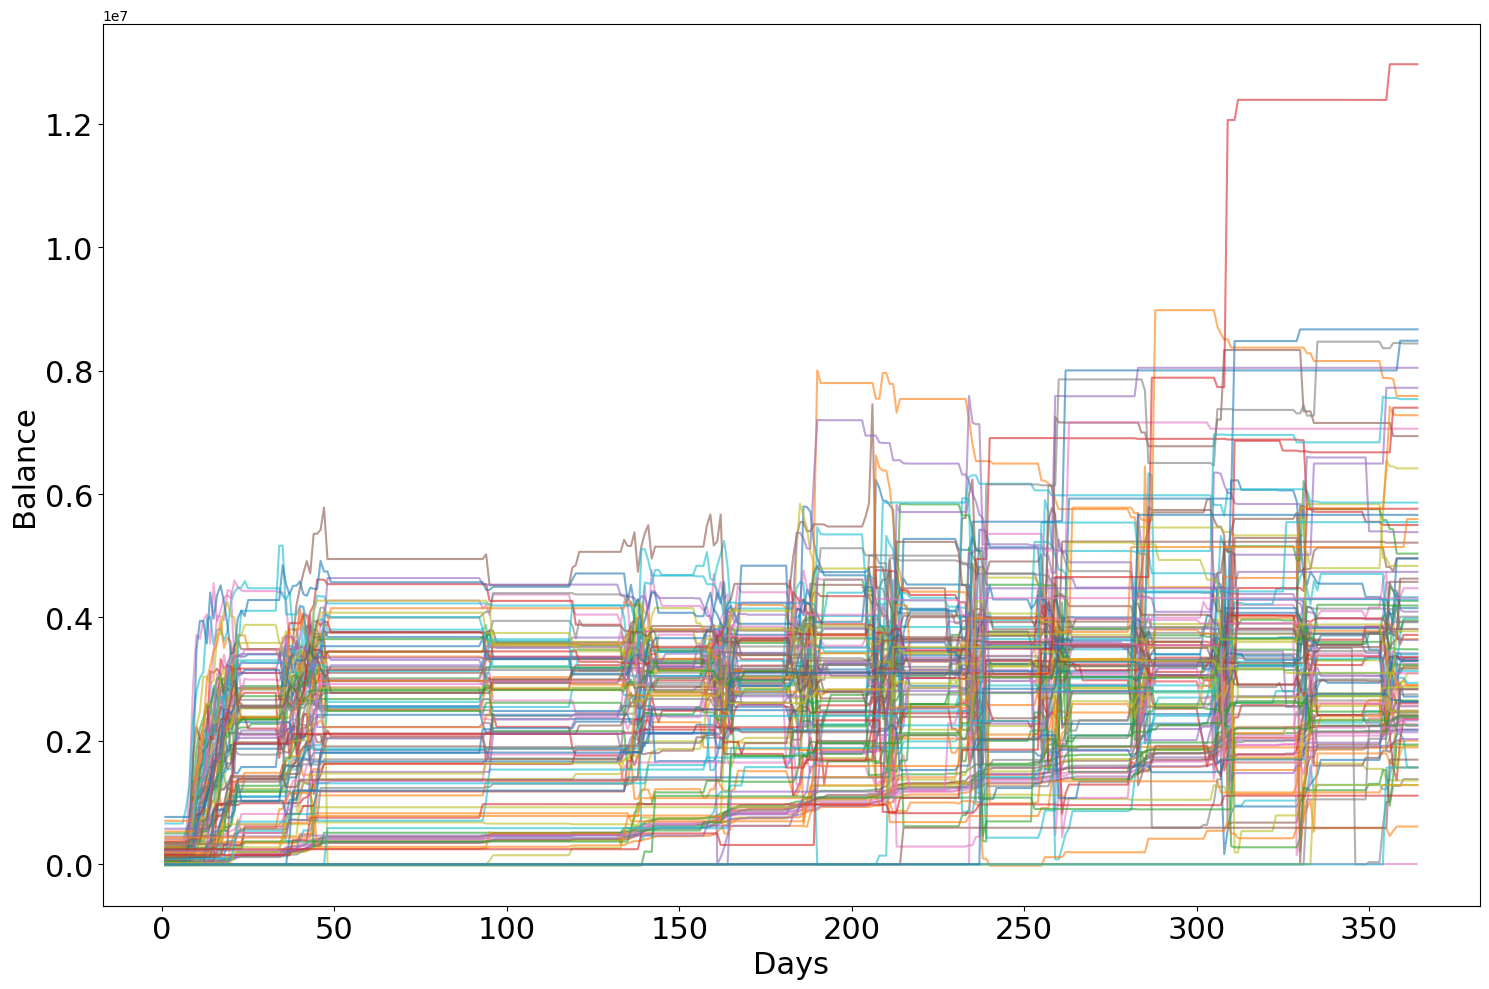

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           111 x 364 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.09e-04 nnz(S)/p=1.09e+02
* iter=1 time=3.54e-03 obj=6.55e+01 |delta(obj)|/obj=6.80e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.00e+00] lns_iter=7 
* iter=2 time=6.20e-03 obj=5.60e+01 |delta(obj)|/obj=1.69e-01 nnz(X,L,W)/p=[1.09e+02 5.45e+01 1.02e+02] lns_iter=9 
* iter=3 time=4.48e-02 obj=3.86e+01 |delta(obj)|/ob

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [22]:
from workflow.internal import *

if __name__ == '__main__':
    # Load dataset (the user will pass the name)
    df, name, dimension = load_dataset()

    # Extract time series
    extract_timeseries(df)

    # Normalise time series
    Y_norm = normalization(df, name)

    # Run SQUIC_fit
    adjaceny_matrices, table_results, lambdas = squic_computation(Y_norm, name, dimension)
    
    # Use the extracted W for clustering
    dict_cluster = clustering(adjaceny_matrices, lambdas)

    # Report internal metrics on the clustering
    int_metrics = internal_metrics(dict_cluster, adjaceny_matrices, lambdas)

    visualize_metrics(int_metrics, lambdas)

    # Visualise with cosmograph
    create_graph(adjaceny_matrices, dict_cluster, lambdas, name, dimension)